# Experiment 4 — budget-reallocation pilot
**Question:** Do disasters cause abnormal downward revisions to pre-planned ordinary infrastructure, especially at weaker-capacity councils?

Five councils, two event groups. This notebook reconstructs and checks measurement; no models. **NO-GO for causal scaling with the current public-data reconstruction.** Earlier experiments preserved.

In [1]:
from pathlib import Path
import json, runpy
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'NSW Data Panel.csv').exists():
    ROOT = Path('/Users/ray/Research/AUSSEF')
OUT = ROOT / 'Experiment 4/results'
checks = runpy.run_path(str(OUT / 'reproduce.py'))['build'](OUT)
pd.Series(checks)

councils                                                                         5
category_chains                                                                 79
stage_records                                                                  395
observed_stage_values                                                          312
missing_stage_values                                                            83
project_revision_records                                                        32
certified_ordinary_model_rows                                                    0
models_fitted                                                                    0
frozen_files_checked                                                          1102
frozen_files_changed                                                            []
source_files_hashed                                                            209
known_source_errors_retained                                                     2
verd

## 1. Budget paths
Annual forecasts at each review, not spending during the quarter. Scopes differ. Lismore is quarantined for year/unit conflicts; Eurobodalla Q3 approval is unverified. Missing is not zero.

,council_key,financial_year,B0_aud,Q1_aud,Q2_aud,Q3_aud,ACTUAL_aud
0,richmondvalley,2021-22,46880556.0,49339614,45706468,38584669,NaN
1,eurobodalla,2019-20,75418007.0,65694767,47122414,43393946,NaN
2,lismore,2021-22,66170200.0,67799700,70436000,49932200,NaN
3,griffith,2019-20,40932455.0,48535638,49468828,34700588,NaN
4,waggawagga,2021-22,NaN,158777354,132452986,128413693,NaN


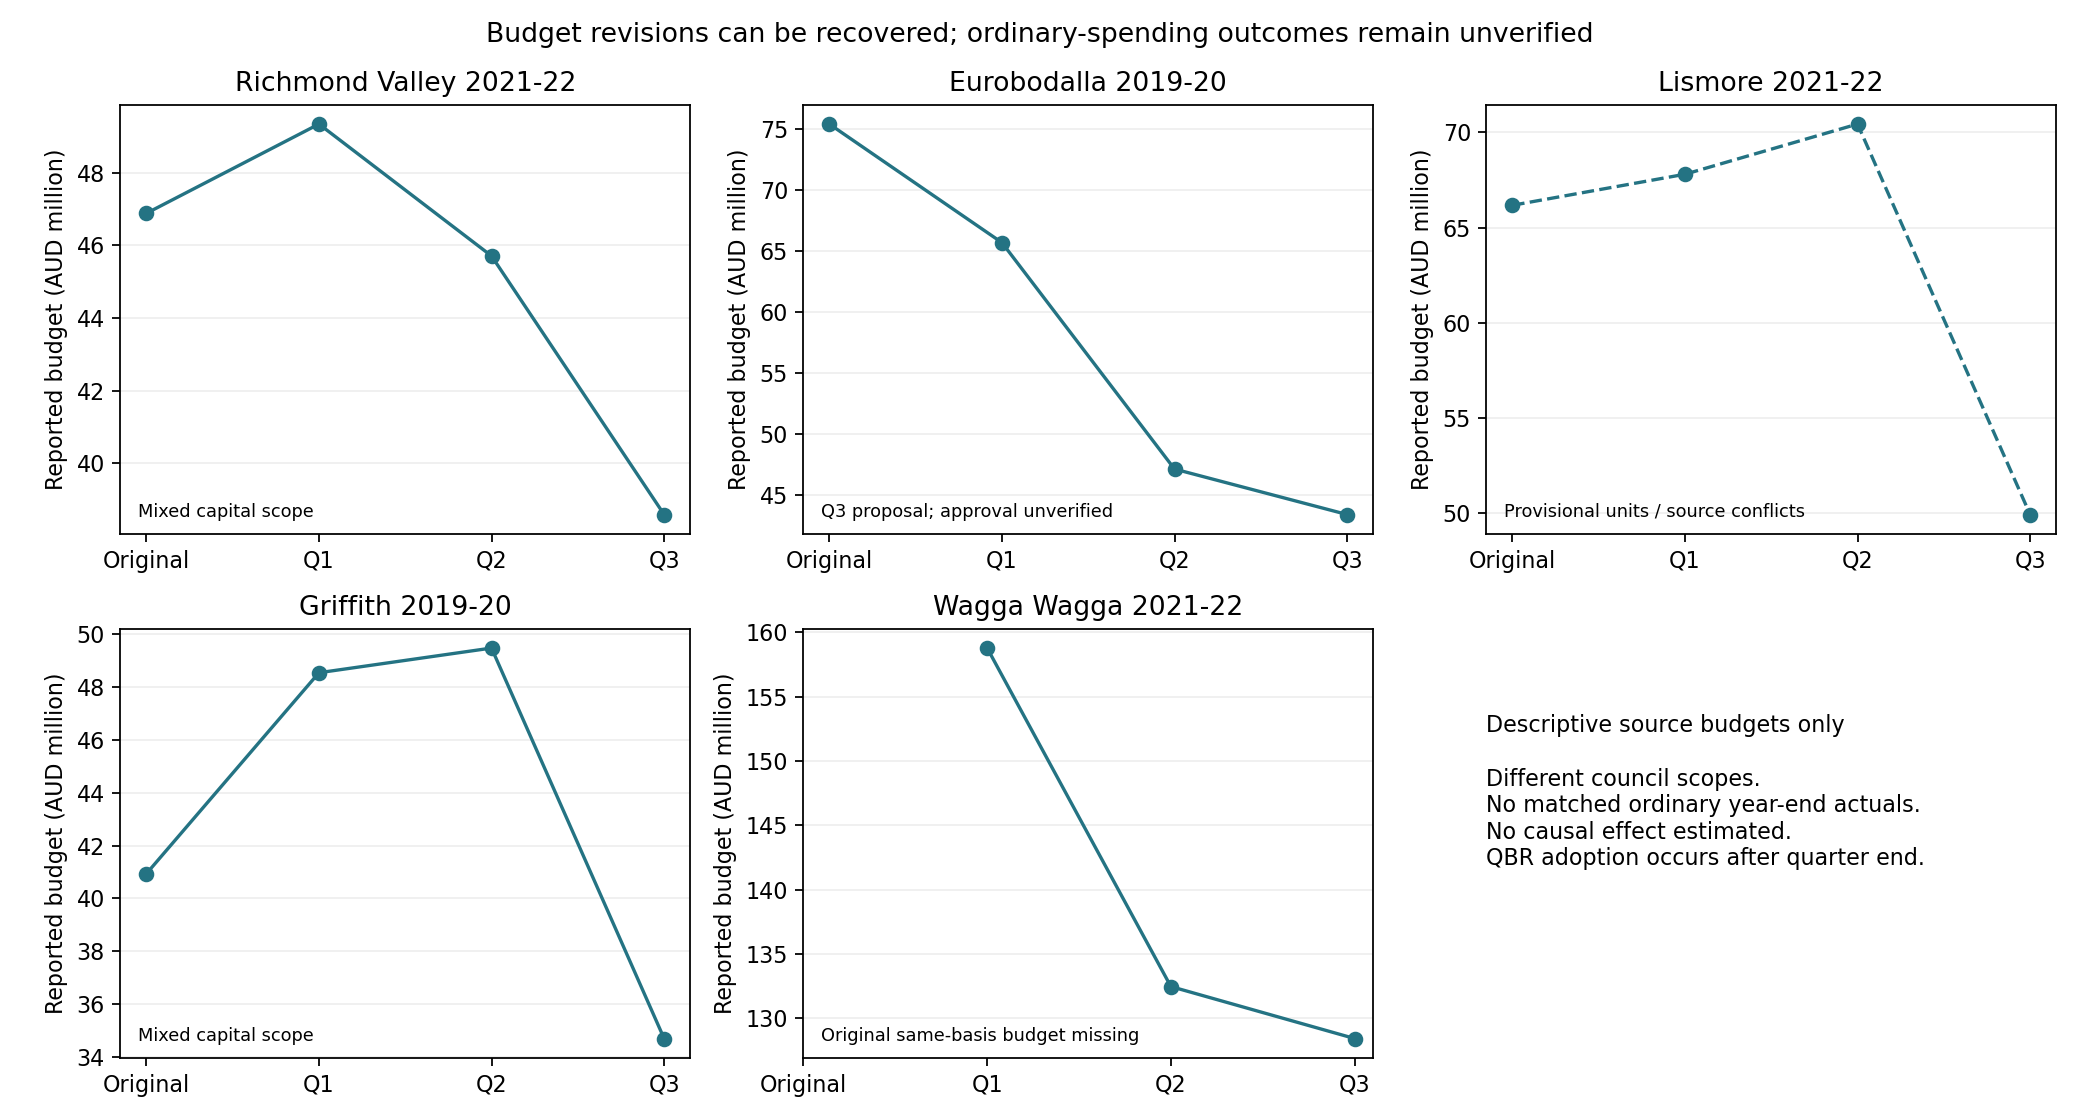

In [2]:
summary = pd.read_csv(OUT / 'quarterly_summary.csv')
display(summary[['council_key','financial_year','B0_aud','Q1_aud','Q2_aud','Q3_aud','ACTUAL_aud']])
display(Image(filename=str(OUT / 'budget_paths.png')))

## 2. Annual actuals are separate
Audited cash-IPPE pairs cover all capital. They cannot fill missing ordinary-category actuals. A negative annual deviation does not establish an abnormal disaster effect.

In [3]:
annual = pd.read_csv(OUT / 'annual_cash_pairs.csv')
display(annual[['council_key','original_budget_aud','actual_aud','deviation_pct']])
display(pd.read_csv(OUT / 'coverage_and_exclusions.csv'))

,council_key,original_budget_aud,actual_aud,deviation_pct
0,richmondvalley,43690000,26431000,-39.503319
1,lismore,64888000,32656000,-49.673283
2,griffith,40933000,22210000,-45.740600
3,eurobodalla,75418000,39541000,-47.570872
4,waggawagga,133279000,82534000,-38.074265


,council_key,category_chains,ordinary_scope_certified,complete_ordinary_chains,excluded_from_causal_modelling,exclusion,B0_observed,B0_missing,Q1_observed,Q1_missing,Q2_observed,Q2_missing,Q3_observed,Q3_missing,ACTUAL_observed,ACTUAL_missing
0,eurobodalla,24,0,0,24,No certified fixed ordinary portfolio with mat...,24,0,24,0,24,0,24,0,0,24
1,griffith,5,0,0,5,No certified fixed ordinary portfolio with mat...,5,0,5,0,5,0,5,0,0,5
2,lismore,14,0,0,14,No certified fixed ordinary portfolio with mat...,14,0,14,0,14,0,14,0,0,14
3,richmondvalley,32,0,0,32,No certified fixed ordinary portfolio with mat...,32,0,32,0,32,0,32,0,0,32
4,waggawagga,4,0,0,4,No certified fixed ordinary portfolio with mat...,0,4,4,0,4,0,4,0,0,4


## 3. Disaster and decision timing
Separate event start, local impact, reporting cutoff and adoption. Lismore's December review was adopted February16. Eurobodalla's September revision preceded major December31 impact but was adopted on the fire's ignition date. Prior/follow-on floods and COVID matter.

In [4]:
display(pd.read_csv(OUT / 'decision_dates.csv')[['council_key','stage','reference_period_end','decision_date','decision_status']])
display(pd.read_csv(OUT / 'event_timeline.csv').head(7)[['council_key','date','date_type','limitation']])

,council_key,stage,reference_period_end,decision_date,decision_status
0,richmondvalley,Q1,2021-09-30,2021-10-19,approved_verified_minutes
1,richmondvalley,Q2,2021-12-31,2022-02-15,approved_verified_minutes
2,richmondvalley,Q3,2022-03-31,2022-05-17,approved_verified_minutes
3,lismore,Q1,2021-09-30,2021-11-09,approved_verified_minutes
4,lismore,Q2,2021-12-31,2022-02-16,approved_verified_minutes
5,lismore,Q3,2022-03-31,2022-05-10,approved_verified_minutes
6,griffith,Q1,2019-09-30,2019-11-26,approved_verified_minutes
7,griffith,Q2,2019-12-31,2020-02-25,approved_verified_minutes
8,griffith,Q3,2020-03-31,2020-05-26,approved_verified_minutes
9,waggawagga,Q1,2021-09-30,2021-10-25,approved_verified_minutes


,council_key,date,date_type,limitation
0,lismore,2022-02-22,DRFA event start,"Regional activation start, not local flood onset"
1,richmondvalley,2022-02-22,DRFA event start,"Regional activation start, not local flood onset"
2,lismore,2022-02-28,Local gauge flood peak,14.4m; does not specify first damage time to e...
3,richmondvalley,2022-02-28,Local extreme rainfall date,Casino daily rainfall; flood arrival varies by...
4,eurobodalla,2019-11-26,Fire ignition,"Currowan ignition; same date as Q1 adoption, n..."
5,eurobodalla,2019-12-31,Major local fire impact,Major impact day; other firestorm days in Janu...
6,eurobodalla,2020-02-10,Local flood event,Q3 also contains flood and COVID disruption


## 4. Ordinary candidates, repairs and rephasing
Richmond's roads reduction includes old disaster claims closed after redamage. Wagga jobs move between years without reducing lifetime budgets. Ordinary candidates still lack certified damage/access and final actuals. This is a selected evidence register, not a complete project universe.

In [5]:
projects = pd.read_csv(OUT / 'project_revision_register.csv')
display(projects[['council_key','project_label','official_project_id','spending_class','budget_revision_aud','rephased_to_fy']])
display(pd.read_csv(OUT / 'year_end_followup.csv')[['action_id','reported_action_status','interpretation']])

,council_key,project_label,official_project_id,spending_class,budget_revision_aud,rephased_to_fy
0,richmondvalley,Casino Swimming Pool upgrade,NaN,ordinary_candidate,-1600000,2022-23
1,richmondvalley,Casino Lawn Cemetery concrete strips,NaN,ordinary_candidate,-40000,NaN
2,richmondvalley,Coraki Riverside Pontoon Extension,NaN,ordinary_candidate,-41923,2022-23
3,richmondvalley,Woodburn Riverside Park Jetty Upgrade,NaN,ordinary_candidate,-63393,2022-23
4,richmondvalley,Casino Showground Planning and Design,NaN,ordinary_candidate,-550000,2022-23
5,richmondvalley,Country Lane rehabilitation,NaN,ordinary_candidate,-150000,2022-23
6,richmondvalley,Richmond Terrace rehabilitation,NaN,ordinary_candidate,-70000,2022-23
7,richmondvalley,Naughtons Gap Road Fixing Local Roads,NaN,direct_damage_or_reconstruction,-484008,2022-23
8,richmondvalley,AGRN960 Essential Public Asset Restoration,NaN,disaster_reconstruction,-1245243,2022-23
9,richmondvalley,Cell 6 approval and construction,NaN,ordinary_candidate,-1000000,2022-23


,action_id,reported_action_status,interpretation
0,PP1.4.4,Completed,Masterplan complete; Stage1 construction comme...


## 5. Cleaning and suitability
No imputation. Signed revisions and negative source balances retained. Arithmetic, units and status checked rather than silently corrected. Multiple rows share council/event exposure and capacity.

In [6]:
quality = pd.read_csv(OUT / 'reconciliation_checks.csv')
display(quality[quality.status != 'pass'])
display(pd.read_csv(OUT / 'cleaning_log.csv')[['issue_id','council_key','finding','treatment']])
display(pd.read_csv(OUT / 'comparison_screen.csv')[['council_key','mapped_burn_status','physical_flood_status','causal_control_eligible']])
display(pd.read_csv(OUT / 'capacity_availability.csv')[['council_key','pre_cash_cover_months','pre_operating_ratio_pct','pre_event_publication_verified']])

,check,council_key,stage,residual_aud,status
1,category_sum,eurobodalla,Q1,1.0,rounding_flag
2,category_sum,eurobodalla,Q2,1.0,rounding_flag
3,category_sum,eurobodalla,Q3,1.0,rounding_flag
16,category_sum,waggawagga,B0,NaN,not_testable
20,euro_rollforward_TR,eurobodalla,Q3,-1.0,rounding_flag
21,euro_rollforward_TOTAL,eurobodalla,Q3,-1.0,rounding_flag
22,reported_oneoff_movement,waggawagga,Q1,1000000.0,fail_retained
23,QBR_original_vs_audited_original,griffith,B0,545.0,fail_retained


,issue_id,council_key,finding,treatment
0,C01,all,Year-end category/project actual is not matche...,blocks annual outcome
1,C02,all,"Cash IPPE, full capital, ordinary infrastructu...",blocks automatic joining
2,C03,all,Quarter end differs from approval/publication;...,decision_dates.csv
3,C04,lismore,"QBR capital pages say $000 and 2020/21, surrou...",council clarification required
4,C05,lismore,Q3 renewal Other projects ends as negative exp...,blocks category interpretation
5,C06,lismore,May10 resolution adds $5m reserve transfer; no...,do not claim full approved funding reconstruction
6,C07,waggawagga,"Sep one-off: 97,965,275 + 2,000,585 !=100,965,...",reported levels retained; movement not repaired
7,C08,eurobodalla,Capital sums/rollforward have AUD1 discrepancies,retain reported figures and tolerance flag
8,C09,griffith,"QBR original IPPE40,932,455 vs accounts40,933,...",reconcile before exact annual chain
9,C10,richmondvalley,"Roads decrease contains1,245,243 prior disaste...",exclude from ordinary displacement


,council_key,mapped_burn_status,physical_flood_status,causal_control_eligible
0,griffith,verified_zero_mapped_burn_within_source_scope,unknown_no_complete_inundation_footprint,False
1,waggawagga,verified_zero_mapped_burn_within_source_scope,unknown_no_complete_inundation_footprint,False


,council_key,pre_cash_cover_months,pre_operating_ratio_pct,pre_event_publication_verified
0,eurobodalla,14.07,3.43,False
1,griffith,11.41,6.30,False
2,lismore,13.33,-9.93,False
3,richmondvalley,11.31,-4.10,False
4,waggawagga,12.78,-6.72,False


## 6. Decision
**NO-GO for final causal modelling or immediate scaling.** Records establish reported revisions and deferrals, not a certified ordinary-spending effect or capacity mechanism. **Zero certified model-ready ordinary outcome rows.**

Next: versioned project budgets/actuals with stable IDs, damage/access and completion records; comparable pre/post portfolios; validated controls and fiscal vintages. See PILOT_REPORT.md for citations and minimum_additional_data.csv for precise fields. No outreach sent.

In [7]:
display(pd.read_csv(OUT / 'feasibility_gates.csv'))
assert checks['frozen_files_changed'] == []
assert checks['models_fitted'] == 0
assert pd.read_csv(OUT / 'model_ready_ordinary_panel.csv').empty
print(f"Preserved {checks['frozen_files_checked']} existing files; no models fitted.")

,gate,verdict,reason
0,Quarterly budget reconstruction,PARTIAL GO,Records recovered for five councils; same-sour...
1,Annual ordinary outcome,NO-GO,Five audited all-capital cash pairs exist; no ...
2,Project deferrals,PARTIAL GO,Documented rephasing/reclassification; IDs and...
3,Disaster timing,PARTIAL GO,Exact event/impact dates distinguished; asset ...
4,Comparison validity,NO-GO,Griffith and Wagga screened; not validated unt...
5,Fiscal-capacity interaction,NO-GO,Economic prior measures exist; vintage and ind...
6,Modelling readiness,NO-GO,Clean audit tables are appropriate for descrip...
7,Scale to causal study now,NO-GO,Administrative fixed-portfolio reconstruction ...


Preserved 1102 existing files; no models fitted.
